In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#url = 'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins.csv'
#url2 =  'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins-raw.csv'

url = './data/penguins.csv'
penguins = pd.read_csv(url)

print(penguins.shape)
penguins.head()

(344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [2]:
# Create df for ML
df = penguins
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

---
## Classification
---

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
# ---------------------------------------------------
# 1) X, y Definitions
# ---------------------------------------------------

# Target = species (already has Adelie / Chinstrap / Gentoo)
df = df.dropna(subset=["species"])

# Feature groups
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
cat_cols = ["island", "sex"]

X = df[num_cols + cat_cols]
y = df["species"]

In [5]:
# ---------------------------------------------------
# 1b) Optional - Drop nulls before the Pipeline
# ---------------------------------------------------

df.shape

(344, 8)

## Pipeline Importance

* No data leakage: Preprocessing is fit on training data only and applied to test data using the training parameters.
* Cleaner CV (cross-validation): When you run cross‑validation, each fold fits its own preprocessing inside the fold, which is the correct procedure.
* Deployable: You can serialize (joblib.dump) and deploy clf as a single object. Any future .predict() call will automatically apply the same preprocessing before classification.
* Less code, fewer bugs: You don’t have to remember to scale/encode at prediction time—Pipeline does it for you.

**Numeric Pipeline**  
1. Imputer (median)  
    * Fills in missing numeric values using the median of each column.  
    * Median is robust to outliers and works well for measurement data.  

2. StandardScaler  
    * Scales numeric values so they have mean = 0 and standard deviation = 1.
    * Essential because many models (like Logistic Regression, SVM, KNN) perform better when features are on the same scale.

**Categorical Pipeline**  
1. Imputer (most_frequent)  
    * Fills missing categories with the most common value in each column.
2. OneHotEncoder  
    * Converts categories (e.g., "Male", "Female", "Biscoe", "Dream", "Torgersen") into dummy variables.
    * handle_unknown="ignore" prevents errors when the model sees a new category in test or production data.

**Combine the Pipelines**  
* Imputes and scales numeric features
* Imputes and encodes categorical features
* Outputs a fully transformed feature matrix ready for modeling

In [6]:
# ---------------------------------------------------
# 2) Preprocessing Pipelines
# ---------------------------------------------------
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop='first'))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])


In [7]:
numeric_pipeline
categorical_pipeline
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## End-to-end model

* Pipeline([...]) chains steps together so you can fit, predict, and cross‑validate the entire workflow as one object.

In [13]:
clf = Pipeline([("preprocess", preprocess),
               ("model", RandomForestClassifier(n_estimators=300, random_state=42))])

In [14]:
clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Cross-validation
* cross_val_score splits the dataset into 5 equal folds.
* For each fold:
    1. The model (clf) trains on 4 folds
    2. It is tested on the remaining 1 fold
* This repeats 5 times, each time with a different fold as the test set.  
This produces **five accuracy values**, one per fold.


**Why cross‑validation matters**  

* A single train/test split may be lucky or unlucky.
* Cross‑validation reduces this risk by averaging performance across multiple splits.
* It gives a more stable and trustworthy estimate of model quality.



In [15]:
# ---------------------------------------------------
# 4) Train-Test Split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, stratify=y
)

# ---------------------------------------------------
# 5) Fit the model
# ---------------------------------------------------
clf.fit(X_train, y_train)

# ---------------------------------------------------
# 6) Evaluate performance
# ---------------------------------------------------
y_pred = clf.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

Test Accuracy: 0.9737

Classification Report:

              precision    recall  f1-score   support

      Adelie      0.980     0.960     0.970        50
   Chinstrap      0.958     1.000     0.979        23
      Gentoo      0.976     0.976     0.976        41

    accuracy                          0.974       114
   macro avg      0.971     0.979     0.975       114
weighted avg      0.974     0.974     0.974       114



In [16]:
# Cross-validated accuracy for overall stability
cv_scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(f"CV Mean Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std: {cv_scores.std():.4f}")

CV Mean Accuracy: 0.9884
CV Std: 0.0058


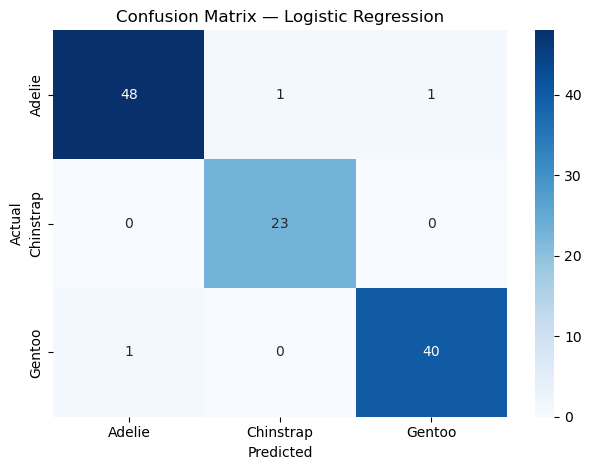

In [17]:
# ---------------------------------------------------
# 7) Confusion Matrix Plot
# ---------------------------------------------------
labels = ["Adelie", "Chinstrap", "Gentoo"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

In [ ]:
# Find the mis-identified Penguin!